# Constraint experiments

Shared data and architecture; separate cells for none, soft, and hard constraints.

In [23]:
from pathlib import Path

DATA = Path("bunny_cross_sections_8slices.npz")
assert DATA.is_file(), DATA

In [24]:
from dataclasses import dataclass
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.ndimage import label as connected_components
from skimage.measure import marching_cubes

TRAIN_RES = 64
BASE_CHANNELS = 16
LEARNING_RATE = 5e-4
TRUNCATION = 0.1
SEED = 11
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_num_threads(max(1, min(8, torch.get_num_threads())))
print(DEVICE)

cuda


## Data

In [25]:
flat_masks = slice_mask_np.reshape(num_planes, -1)
voxels_on_any_plane = np.any(flat_masks, axis=0)
total_voxels = voxels_on_any_plane.size
covered_voxels = int(np.sum(voxels_on_any_plane))
percentage_covered = (covered_voxels / total_voxels) * 100

print("--- Data Density Analysis ---")
print(f"Total Voxels in 3D Grid : {total_voxels:,}")
print(f"Voxels on Input Planes  : {covered_voxels:,}")
print(f"Direct Spatial Coverage : {percentage_covered:.2f}%")

--- Data Density Analysis ---
Total Voxels in 3D Grid : 262,144
Voxels on Input Planes  : 32,355
Direct Spatial Coverage : 12.34%


In [26]:
with np.load(DATA) as archive:
    slice_grid_axis_np = archive["grid_axis"].astype(np.float32)
    plane_normals_np = archive["plane_normals"].astype(np.float32)
    plane_distance_np = archive["plane_distance"].astype(np.float32)
    slice_mask_np = archive["slice_mask"].astype(bool)
    sdf2d_per_plane_np = archive["sdf2d"].astype(np.float32)
    contour_vertices_np = archive["contour_vertices"].astype(np.float32)
    contour_edges_np = archive["contour_edges"].astype(np.int64)
    contour_plane_np = archive["contour_plane"].astype(np.int64)

num_planes = int(plane_normals_np.shape[0])
source_resolution = int(len(slice_grid_axis_np))
source_spacing = float(abs(slice_grid_axis_np[1] - slice_grid_axis_np[0]))
grid_lower = float(slice_grid_axis_np[0])
grid_upper = float(slice_grid_axis_np[-1])

grid_points_np = np.stack(
    np.meshgrid(slice_grid_axis_np, slice_grid_axis_np, slice_grid_axis_np, indexing="ij"), 
    axis=-1
).reshape(-1, 3)

SIGN_EXCLUSION = 0.75 * source_spacing
plane_banks = []

for plane_id in range(num_planes):
    slab_mask_flat = slice_mask_np[plane_id].reshape(-1)
    slab_xyz = grid_points_np[slab_mask_flat]
    signed_distance_to_plane = plane_distance_np[plane_id].reshape(-1)[slab_mask_flat]
    
    normal = plane_normals_np[plane_id]
    normal_norm_squared = float(np.dot(normal, normal))
    if normal_norm_squared <= 1.0e-12:
        raise ValueError(f"Plane {plane_id} has an invalid normal.")

    exact_plane_xyz = slab_xyz - (signed_distance_to_plane / normal_norm_squared)[:, None] * normal[None, :]
    exact_sdf2d = sdf2d_per_plane_np[plane_id].reshape(-1)[slab_mask_flat]

    valid = np.all((exact_plane_xyz >= grid_lower - 1.0e-6) & (exact_plane_xyz <= grid_upper + 1.0e-6), axis=1)
    exact_plane_xyz = np.clip(exact_plane_xyz[valid], grid_lower, grid_upper).astype(np.float32)
    exact_sdf2d = exact_sdf2d[valid].astype(np.float32)

    inside = exact_sdf2d < -SIGN_EXCLUSION
    outside = exact_sdf2d > SIGN_EXCLUSION

    if not inside.any() or not outside.any():
        raise RuntimeError(f"Plane {plane_id} missing sign samples.")

    plane_banks.append({
        "all_xyz": torch.from_numpy(exact_plane_xyz).to(DEVICE),
        "all_sdf2d": torch.from_numpy(exact_sdf2d).to(DEVICE),
        "inside_xyz": torch.from_numpy(exact_plane_xyz[inside]).to(DEVICE),
        "inside_sdf2d": torch.from_numpy(exact_sdf2d[inside]).to(DEVICE),
        "outside_xyz": torch.from_numpy(exact_plane_xyz[outside]).to(DEVICE),
        "outside_sdf2d": torch.from_numpy(exact_sdf2d[outside]).to(DEVICE),
    })

edge_start_plane = contour_plane_np[contour_edges_np[:, 0]]
edge_end_plane = contour_plane_np[contour_edges_np[:, 1]]

if not np.array_equal(edge_start_plane, edge_end_plane):
    raise ValueError("A contour edge connects vertices from different planes.")

contour_banks = []
for plane_id in range(num_planes):
    plane_edges = contour_edges_np[edge_start_plane == plane_id]
    if len(plane_edges) == 0:
        raise RuntimeError(f"Plane {plane_id} has no contour edges.")

    v0 = contour_vertices_np[plane_edges[:, 0]]
    v1 = contour_vertices_np[plane_edges[:, 1]]
    edge_lengths = np.linalg.norm(v1 - v0, axis=1)
    
    nondegenerate = edge_lengths > 1.0e-10
    v0, v1, edge_lengths = v0[nondegenerate], v1[nondegenerate], edge_lengths[nondegenerate]

    if len(edge_lengths) == 0:
        raise RuntimeError(f"Plane {plane_id} has only degenerate edges.")

    edge_probability = (edge_lengths / edge_lengths.sum()).astype(np.float32)

    contour_banks.append({
        "v0": torch.from_numpy(v0.astype(np.float32)).to(DEVICE),
        "v1": torch.from_numpy(v1.astype(np.float32)).to(DEVICE),
        "probability": torch.from_numpy(edge_probability).to(DEVICE),
    })

target_size = (TRAIN_RES, TRAIN_RES, TRAIN_RES)
train_axis = np.linspace(grid_lower, grid_upper, TRAIN_RES, dtype=np.float32)
train_grid_xyz = np.stack(np.meshgrid(train_axis, train_axis, train_axis, indexing="ij"), axis=-1).reshape(-1, 3)

contour_tree = cKDTree(contour_vertices_np)
d2d_unsigned_np, _ = contour_tree.query(train_grid_xyz)
d2d_unsigned = torch.from_numpy(d2d_unsigned_np.reshape(1, 1, *target_size)).to(DEVICE, dtype=torch.float32)

with np.load(DATA) as archive:
    sdf2d_all = torch.from_numpy(archive["sdf2d"].astype(np.float32)).unsqueeze(0).to(DEVICE)
    plane_distance_all = torch.from_numpy(archive["plane_distance"].astype(np.float32)).unsqueeze(0).to(DEVICE)

if sdf2d_all.shape[-3:] != target_size:
    sdf2d_all = F.interpolate(sdf2d_all, size=target_size, mode="trilinear", align_corners=True)
    plane_distance_all = F.interpolate(plane_distance_all, size=target_size, mode="trilinear", align_corners=True)

closest_plane_idx = torch.argmin(plane_distance_all.abs(), dim=1, keepdim=True)
d2d_sign = torch.sign(torch.gather(sdf2d_all, dim=1, index=closest_plane_idx))
d2d_field = d2d_sign * d2d_unsigned

print({
    "number_of_planes": num_planes,
    "plane_candidates": [int(bank["all_xyz"].shape[0]) for bank in plane_banks],
    "contour_edges": [int(bank["v0"].shape[0]) for bank in contour_banks],
    "d2d_field_shape": d2d_field.shape,
})

{'number_of_planes': 8, 'plane_candidates': [3771, 4107, 5125, 3996, 4201, 4037, 3988, 3975], 'contour_edges': [200, 185, 210, 172, 265, 145, 227, 235], 'd2d_field_shape': torch.Size([1, 1, 64, 64, 64])}


## Shared model, losses, and metrics

In [30]:
class Block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        groups = min(4, out_channels)
        self.layers = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(),
            nn.Conv3d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(),
        )

    def forward(self, x):
        return self.layers(x)


class UNet3D(nn.Module):
    def __init__(self, in_channels=6, base=4):
        super().__init__()
        self.enc1 = Block(in_channels, base)
        self.enc2 = Block(base, 2 * base)
        self.bridge = Block(2 * base, 4 * base)
        self.pool = nn.MaxPool3d(2)
        self.up2 = nn.ConvTranspose3d(4 * base, 2 * base, 2, stride=2)
        self.dec2 = Block(4 * base, 2 * base)
        self.up1 = nn.ConvTranspose3d(2 * base, base, 2, stride=2)
        self.dec1 = Block(2 * base, base)
        self.out = nn.Conv3d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        bridge = self.bridge(self.pool(e2))
        d2 = self.dec2(torch.cat((self.up2(bridge), e2), dim=1))
        d1 = self.dec1(torch.cat((self.up1(d2), e1), dim=1))
        return self.out(d1)


def query_field(pred, xyz):
    xyz_norm = 2.0 * (xyz - grid_lower) / (grid_upper - grid_lower) - 1.0
    grid = xyz_norm.view(1, 1, 1, -1, 3)
    return F.grid_sample(pred, grid, mode="bilinear", align_corners=True).view(-1)


def sample_contour_points(num_samples=2048):
    pts = []
    for bank in contour_banks:
        n = num_samples // len(contour_banks)
        idx = torch.multinomial(bank["probability"], n, replacement=True)
        t = torch.rand(n, 1, device=DEVICE)
        pts.append(bank["v0"][idx] * t + bank["v1"][idx] * (1.0 - t))
    return torch.cat(pts, dim=0)


def run_experiment(STEPS=30000, print_every=1000):
    torch.manual_seed(SEED)
    model = UNet3D(d2d_field.shape[1], BASE_CHANNELS).to(DEVICE)
    nn.init.normal_(model.out.weight, std=1e-4)
    nn.init.constant_(model.out.bias, 0.05)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    spacing = (grid_upper - grid_lower) / (TRAIN_RES - 1)
    history = []

    for step in range(STEPS + 1):
        optimizer.zero_grad()
        pred = model(d2d_field)

        c_pts = sample_contour_points()
        pred_c = query_field(pred, c_pts)
        l_0 = pred_c.abs().mean()

        l_sign = F.softplus(-torch.sign(d2d_field) * pred / 0.02).mean()
        l_bound = F.relu(pred.abs() - d2d_field.abs()).mean()

        dx = torch.diff(pred, dim=2) / spacing
        dy = torch.diff(pred, dim=3) / spacing
        dz = torch.diff(pred, dim=4) / spacing
        grad_norm = torch.sqrt(dx[:, :, :, :-1, :-1]**2 + dy[:, :, :-1, :, :-1]**2 + dz[:, :, :-1, :-1, :]**2 + 1e-8)
        l_eik = (grad_norm - 1.0).square().mean()

        l_min = torch.exp(-100.0 * pred.abs()).mean()

        r_t = min(1.0, step / 5000.0)
        
        w_l0 = 1.0 * l_0
        w_sign = 10.0 * l_sign
        w_bound = 5.0 * l_bound
        w_eik = r_t * 10 * l_eik
        w_min = r_t * 0.02 * l_min
        loss = w_l0 + w_sign + w_bound + w_eik + w_min

        loss.backward()
        optimizer.step()

        history.append({
            "total": float(loss.detach()),
            "l_0": float(l_0.detach()),
            "l_sign": float(l_sign.detach()),
            "l_bound": float(l_bound.detach()),
            "l_eik": float(l_eik.detach()),
            "l_min": float(l_min.detach()),
        })

        if step % print_every == 0:
            print(f"Step {step}/{STEPS} | Total: {loss.detach().item():.5f} | L_0: {w_l0.detach().item():.5f} | L_sign: {w_sign.detach().item():.5f} | L_bound: {w_bound.detach().item():.5f} | L_eik: {w_eik.detach().item():.5f} | L_min: {w_min.detach().item():.5f}")

    model.eval()
    return {"model": model, "prediction": pred.detach(), "history": history}


def metrics(prediction):
    predicted_inside = prediction < 0
    true_inside = d2d_field < 0
    intersection = (predicted_inside & true_inside).sum()
    union = (predicted_inside | true_inside).sum().clamp_min(1)
    spacing = (grid_upper - grid_lower) / (TRAIN_RES - 1)
    dx = torch.diff(prediction, dim=2) / spacing
    dy = torch.diff(prediction, dim=3) / spacing
    dz = torch.diff(prediction, dim=4) / spacing
    grad_norm = torch.sqrt(dx[:, :, :, :-1, :-1]**2 + dy[:, :, :-1, :, :-1]**2 + dz[:, :, :-1, :-1, :]**2 + 1e-8)
    l_eik = (grad_norm - 1.0).square().mean()
    return {
        "mae": float(F.l1_loss(prediction, d2d_field)),
        "iou": float(intersection / union),
        "eikonal_error": float(l_eik),
        "bound_excess": float(F.relu(prediction.abs() - d2d_field.abs()).mean()),
    }

results = {}


def visualize_experiment(prediction_tensor, slice_index=None):
    prediction = prediction_tensor.detach().float().cpu()[0, 0].numpy()
    target_np = d2d_field.detach().float().cpu()[0, 0].numpy()
    if slice_index is None:
        slice_index = prediction.shape[0] // 2
    pred_slice = prediction[:, :, slice_index].T
    tgt_slice = target_np[:, :, slice_index].T
    err_slice = np.abs(tgt_slice - pred_slice)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    im0 = axes[0].imshow(tgt_slice, cmap="coolwarm", origin="lower")
    axes[0].set_title("Full ground-truth SDF")
    fig.colorbar(im0, ax=axes[0], shrink=0.8)
    axes[0].contour(tgt_slice, levels=[0], colors="black", linewidths=1.5)

    im1 = axes[1].imshow(pred_slice, cmap="coolwarm", origin="lower")
    axes[1].set_title("slice_only prediction\nblack = target, green = prediction")
    fig.colorbar(im1, ax=axes[1], shrink=0.8)
    axes[1].contour(tgt_slice, levels=[0], colors="black", linewidths=1.5)
    axes[1].contour(pred_slice, levels=[0], colors="lime", linewidths=1.5, linestyles="--")

    im2 = axes[2].imshow(err_slice, cmap="inferno", origin="lower")
    axes[2].set_title(f"Full-SDF absolute error\nmean = {err_slice.mean():.6f}")
    fig.colorbar(im2, ax=axes[2], shrink=0.8)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

Starting Slice-Only Experiment, Training without 3D Ground Truth (weighted losses)
Step 0/10000 | Total: 4.59643 | L_0: 0.05007 | L_sign: 4.54399 | L_bound: 0.00237 | L_eik: 0.00000 | L_min: 0.00000
Step 1000/10000 | Total: 0.31617 | L_0: 0.03390 | L_sign: 0.21381 | L_bound: 0.00353 | L_eik: 0.06489 | L_min: 0.00003
Step 2000/10000 | Total: 0.34318 | L_0: 0.03313 | L_sign: 0.26130 | L_bound: 0.00192 | L_eik: 0.04674 | L_min: 0.00009
Step 3000/10000 | Total: 0.35833 | L_0: 0.03332 | L_sign: 0.28100 | L_bound: 0.00153 | L_eik: 0.04233 | L_min: 0.00015
Step 4000/10000 | Total: 0.36798 | L_0: 0.03348 | L_sign: 0.29651 | L_bound: 0.00119 | L_eik: 0.03657 | L_min: 0.00023
Step 5000/10000 | Total: 0.37425 | L_0: 0.03368 | L_sign: 0.30514 | L_bound: 0.00104 | L_eik: 0.03409 | L_min: 0.00030
Step 6000/10000 | Total: 0.37245 | L_0: 0.03371 | L_sign: 0.30276 | L_bound: 0.00117 | L_eik: 0.03451 | L_min: 0.00029
Step 7000/10000 | Total: 0.37223 | L_0: 0.03360 | L_sign: 0.30455 | L_bound: 0.00113 | 

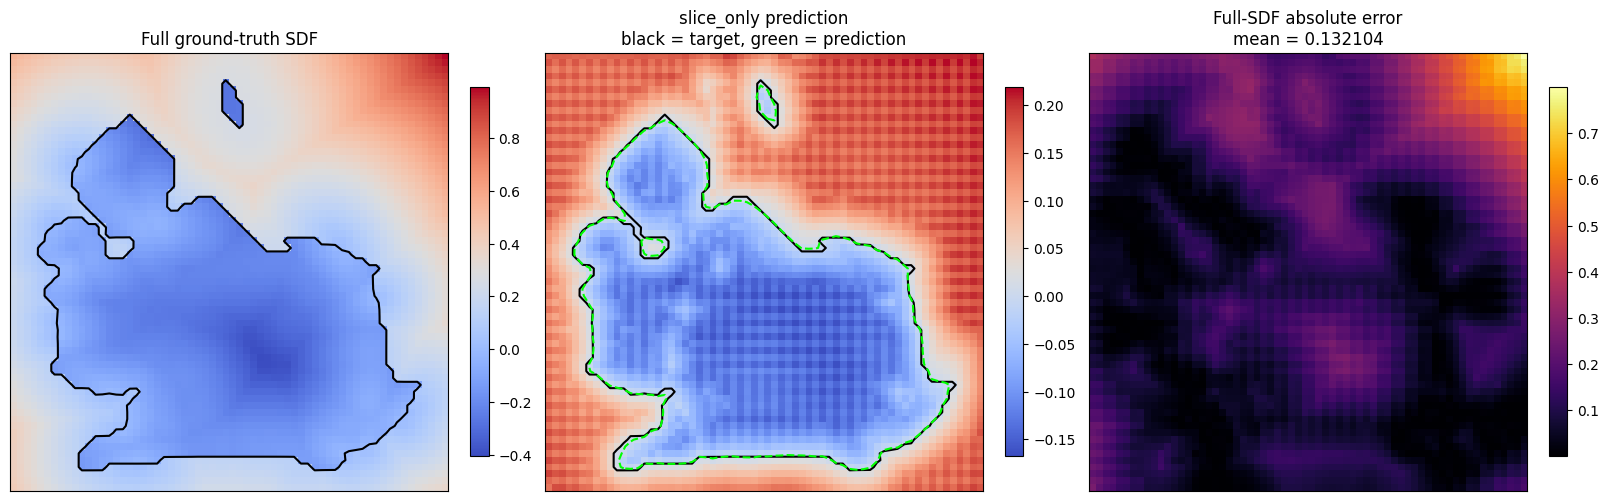

In [32]:
STEPS = 10000
print("Starting Slice-Only Experiment, Training without 3D Ground Truth (weighted losses)")
results["slice_only"] = run_experiment(STEPS=STEPS, print_every=1000)

final_training_terms = results["slice_only"]["history"][-1]
print("\nFinal training terms (unweighted losses):")
print(pd.Series(final_training_terms).to_string())

slice_only_metrics = metrics(results["slice_only"]["prediction"])
print("\nEvaluation metrics:")
print(pd.Series(slice_only_metrics).to_string())

visualize_experiment(results["slice_only"]["prediction"], slice_index=TRAIN_RES // 2)

In [33]:
pred_np = results["slice_only"]["prediction"].detach().cpu().numpy().squeeze().astype(np.float32)
np.savez("slice_only_prediction_8slices.npz", slice_only=pred_np)